### Create two 2D arrays representing coordinates x, y on the cartesian plan

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# Create 1D arrays with 100 points between -2 and 2
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

print(x.shape)
print(y.shape)



(100,)
(100,)


In [3]:
X, Y = np.meshgrid(x, y)

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (100, 100)
Shape of Y: (100, 100)


### Visualize each 2D array using pcolormesh

Text(0.5, 1.0, 'Visualization of Y')

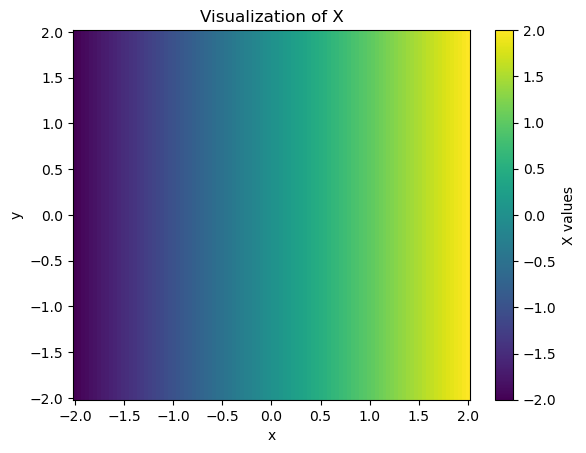

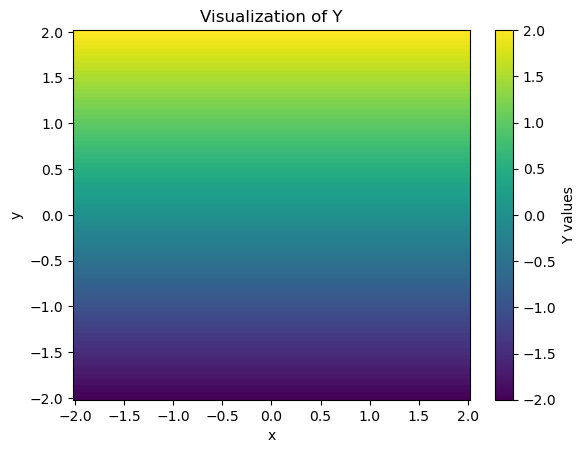

In [4]:
# Plot of X
plt.figure()
plt.pcolormesh(X, Y, X, shading='auto')
plt.colorbar(label='X values')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Visualization of X')


# Plot of Y
plt.figure()
plt.pcolormesh(X, Y, Y, shading='auto')
plt.colorbar(label='Y values')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Visualization of Y')


### From your cartesian coordinates, create polar coordinates r and φ


In [5]:
# Converting to polar coordinates
r = np.sqrt(X**2 + Y**2)
Phi = np.arctan2(Y, X)
#r, Phi = np.meshgrid(r, Phi) is this needed?


### Visualize and r and φ on the 2D  x/y plane using pcolormesh

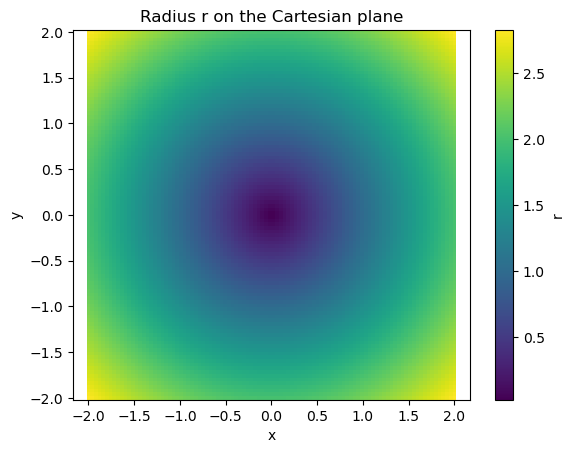

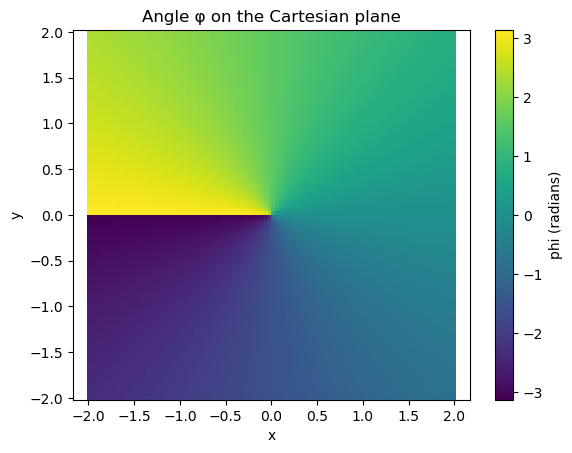

In [6]:
plt.figure()
plt.pcolormesh(X, Y, r, shading='auto')
plt.colorbar(label='r')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Radius r on the Cartesian plane')
plt.axis('equal')
plt.show()

plt.figure()
plt.pcolormesh(X, Y, Phi, shading='auto')
plt.colorbar(label='phi (radians)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Angle φ on the Cartesian plane')
plt.axis('equal')
plt.show()

### Caclulate the quanity f = ...


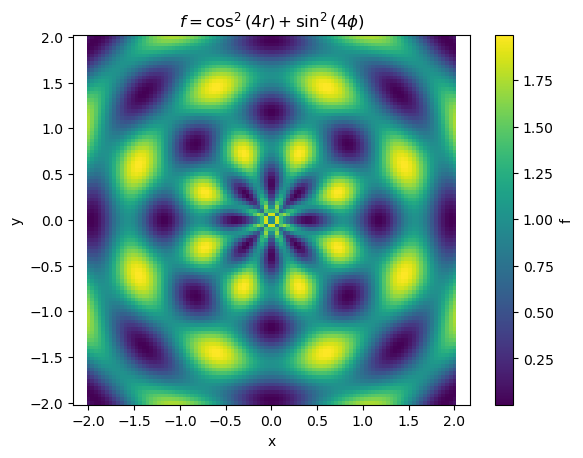

In [7]:
F = np.cos(4*r)**2 + np.sin(4*Phi)**2

# Plot
plt.figure()
plt.pcolormesh(X, Y, F, shading='auto')
plt.colorbar(label='f')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'$f = \cos^2(4r) + \sin^2(4\phi)$')
plt.axis('equal')
plt.show()

### Load each data file as a numpy array.

In [8]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Unzipping contents of '/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip' to '/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip'


['/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/fc2831/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

### Examine the shapes of T, S and P compared to lon, lat, date and level. How do you think they are related?

In [22]:
print(files)

['/home/ep3272/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy', '/home/ep3272/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy', '/home/ep3272/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy', '/home/ep3272/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy', '/home/ep3272/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy', '/home/ep3272/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy', '/home/ep3272/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']


In [9]:
# Example: replace filenames with actual names from the files list
T = np.load([f for f in files if "T" in f][0])
S = np.load([f for f in files if "S" in f][0])
P = np.load([f for f in files if "P" in f][0])
date = np.load([f for f in files if "date" in f][0])
lat = np.load([f for f in files if "lat" in f][0])
lon = np.load([f for f in files if "lon" in f][0])
level = np.load([f for f in files if "level" in f][0])

# Check shapes
print("T shape:", T.shape)
print("S shape:", S.shape)
print("P shape:", P.shape)
print("lon shape:", lon.shape)
print("lat shape:", lat.shape)
print("date shape:", date.shape)
print("level shape:", level.shape)

print("Levels:", level)
print("First lon/lat:", lon[0], lat[0])
print("First profile T:", T[:, 0])

T shape: (78, 75)
S shape: (78, 75)
P shape: (78, 75)
lon shape: (75,)
lat shape: (75,)
date shape: (75,)
level shape: (78,)
Levels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77]
First lon/lat: -39.13 47.187000000000005
First profile T: [18.97400093 18.74099922 18.37000084 17.92099953 17.00200081 16.76199913
 16.53800011 16.34799957 16.29700089 16.14900017 15.98099995 15.88899994
 15.77200031 15.69200039 15.60999966 15.41399956 14.84899998 14.93500042
 14.95100021 14.82299995 14.82199955 14.57600021 14.53999996 14.46399975
 14.39599991 14.30000019 14.21500015 14.04899979 13.93599987 13.8210001
 13.70600033 13.60700035 13.49300003 13.39299965 13.25599957 13.09200001
 12.82299995 12.6079998  12.53499985 12.51099968 12.50500011 12.36100006
 11.99800014 11.94499969 11.90400028 11.01799965 10.74300003

### Make a plot for each column of data in T, S and P (three plots).

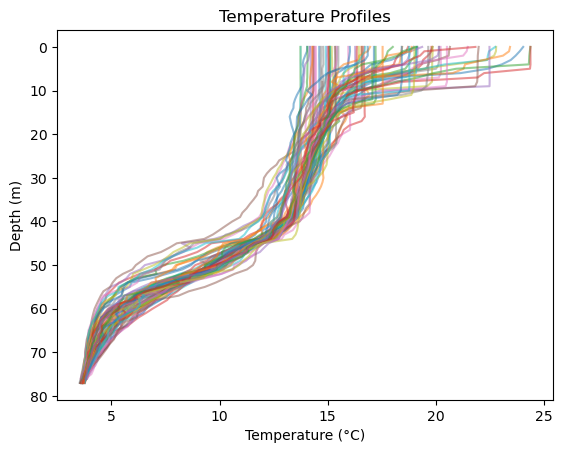

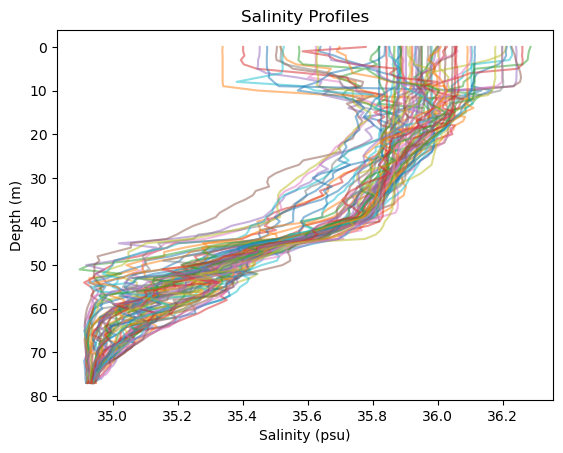

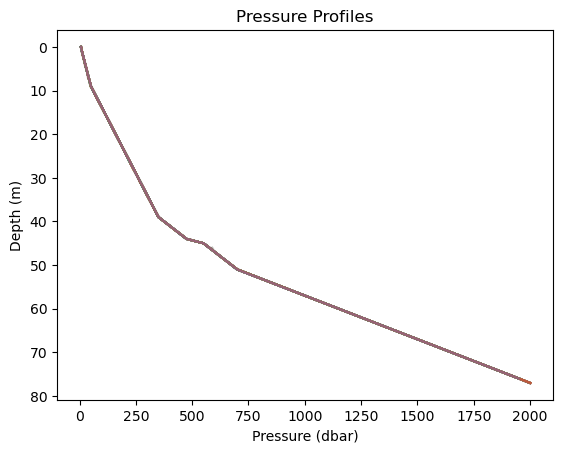

In [10]:
def plot_profiles(data, levels, ylabel, title):
    plt.figure()
    for i in range(data.shape[1]):  # one line per profile
        plt.plot(data[:, i], levels, alpha=0.5)
    plt.gca().invert_yaxis()  # depth increases 
    plt.xlabel(ylabel)
    plt.ylabel('Depth (m)')
    plt.title(title)
    plt.show()

plot_profiles(T, level, 'Temperature (°C)', 'Temperature Profiles')
plot_profiles(S, level, 'Salinity (psu)', 'Salinity Profiles')
plot_profiles(P, level, 'Pressure (dbar)', 'Pressure Profiles')

### Compute the mean and standard deviation of each of T, S and P at each depth in level.

In [11]:
mean_T = np.mean(T, axis=1)
std_T = np.std(T, axis=1)

mean_S = np.mean(S, axis=1)
std_S = np.std(S, axis=1)

mean_P = np.mean(P, axis=1)
std_P = np.std(P, axis=1)

print(mean_T)
print(std_T)
print(mean_S)
print(std_S)
print(mean_P)
print(std_P)


[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan 10.80430666 10.49702667
 10.1749066   9.83453334  9.48625332  9.19793334  8.66010666  8.12324001
  7.60221333  7.15289333  6.74250667  6.39543999  6.04598667  5.74538665
  5.48913333  5.26604001  5.08768     4.93479998  4.77769334  4.65368
  4.54237334  4.44274664  4.35933333         nan         nan         nan
         nan         nan         nan         nan         nan         nan]
[       nan        nan        nan        nan        n

### Now make three similar plot, but show only the mean T, S and P at each depth. Show error bars on each plot using the standard deviations.

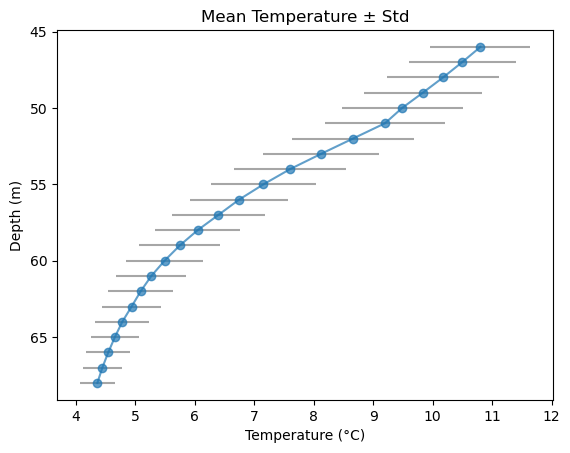

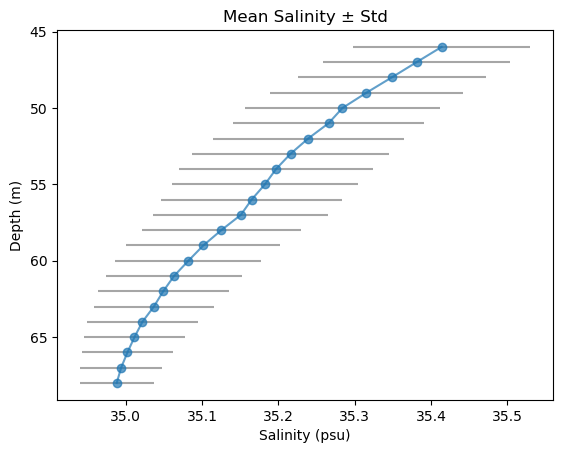

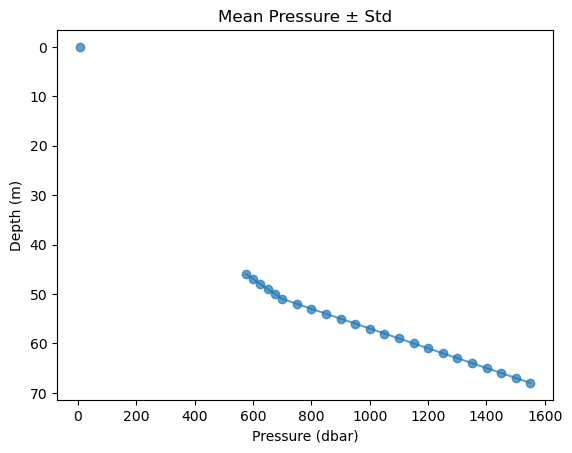

In [12]:
def plot_mean_std(mean, std, levels, ylabel, title):
    plt.figure()
    plt.errorbar(mean, levels, xerr=std, fmt='-o', ecolor='gray', alpha=0.7)
    plt.gca().invert_yaxis()
    plt.xlabel(ylabel)
    plt.ylabel('Depth (m)')
    plt.title(title)
    plt.show()

plot_mean_std(mean_T, std_T, level, 'Temperature (°C)', 'Mean Temperature ± Std')
plot_mean_std(mean_S, std_S, level, 'Salinity (psu)', 'Mean Salinity ± Std')
plot_mean_std(mean_P, std_P, level, 'Pressure (dbar)', 'Mean Pressure ± Std')

### Account For Missing Data

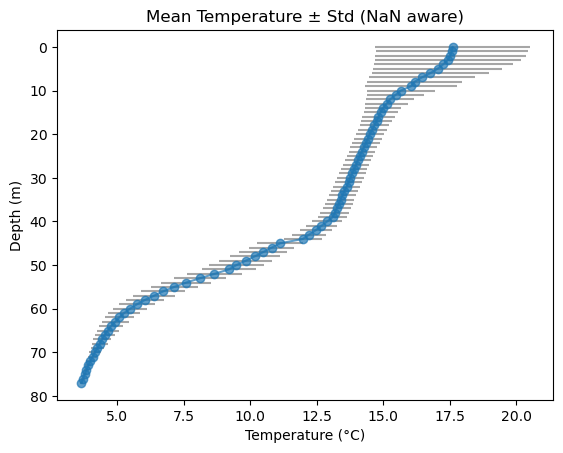

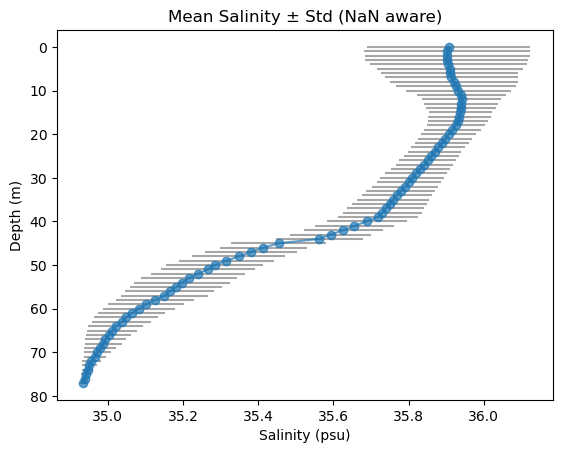

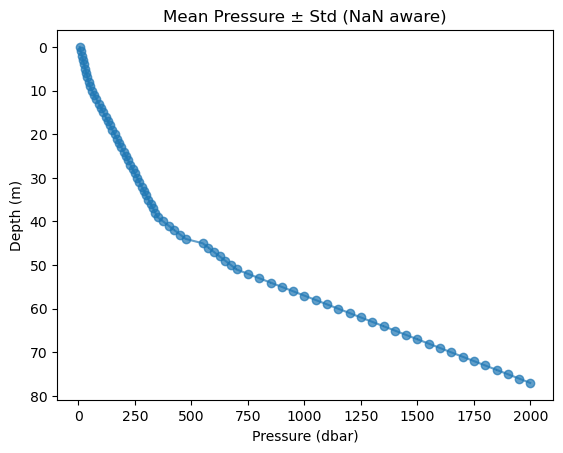

In [13]:
#the "nan" ignores the nans
mean_T_nan = np.nanmean(T, axis=1)
std_T_nan = np.nanstd(T, axis=1)

mean_S_nan = np.nanmean(S, axis=1)
std_S_nan = np.nanstd(S, axis=1)

mean_P_nan = np.nanmean(P, axis=1)
std_P_nan = np.nanstd(P, axis=1)

#Plots
plot_mean_std(mean_T_nan, std_T_nan, level, 'Temperature (°C)', 'Mean Temperature ± Std (NaN aware)')
plot_mean_std(mean_S_nan, std_S_nan, level, 'Salinity (psu)', 'Mean Salinity ± Std (NaN aware)')
plot_mean_std(mean_P_nan, std_P_nan, level, 'Pressure (dbar)', 'Mean Pressure ± Std (NaN aware)')

### Create a scatter plot of the lon, lat positions of the ARGO float.


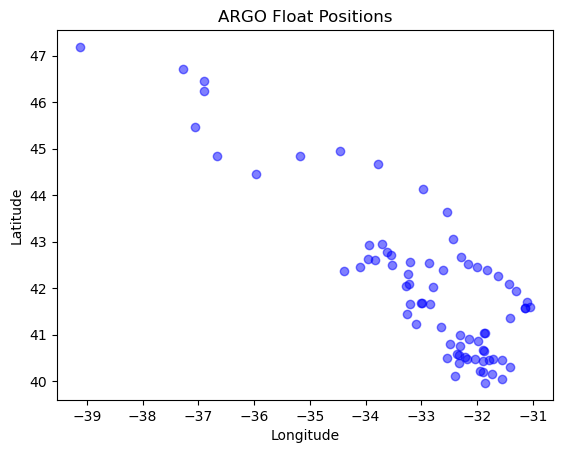

In [14]:
plt.figure()
plt.scatter(lon, lat, c='blue', alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('ARGO Float Positions')
plt.show()